# Regresi Linear

In [12]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [13]:
# Data Preparation
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    '% BB Recycle', 
    'Mean_Load KWH Refiner',
    'Mean_Creping',
    'Mean_Jet Wire Ratio',
    'coating_release_ratio'
]
X = df[features]


# Y Variables
target = 'MDS'
y = df[target]

# Konstanta
X = sm.add_constant(X)

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 185 entries, 0 to 371
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Start_Time              185 non-null    datetime64[us]
 1   End_Time                185 non-null    datetime64[us]
 2   Data_Count              185 non-null    int64         
 3   Mean_Creping            185 non-null    float64       
 4   Mean_Yankee Speed       185 non-null    float64       
 5   Mean_Pope Reel Speed    185 non-null    float64       
 6   Mean_Yankee Pressure    185 non-null    float64       
 7   Mean_Stock Flow         185 non-null    float64       
 8   Mean_Stock Consistency  185 non-null    float64       
 9   Mean_Flow Coating       185 non-null    float64       
 10  Mean_Flow Release       185 non-null    float64       
 11  Mean_Jet Wire Ratio     185 non-null    float64       
 12  Mean_Load KWH Refiner   185 non-null    float64       
 13  Join_K

In [15]:
# Model Regresi Linear
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     238.5
Date:                Mon, 04 May 2026   Prob (F-statistic):           3.75e-77
Time:                        10:34:32   Log-Likelihood:                -316.00
No. Observations:                 185   AIC:                             644.0
Df Residuals:                     179   BIC:                             663.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    15.89

## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [16]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.9053110594463418
Tidak ada autokorelasi (baik positif maupun negatif)


### Indentik (Heterokesdastisitas)

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(8.953345828991209), 'LM-Test p-value': np.float64(0.1109395681117891), 'F-Statistic': np.float64(1.8207093011067847), 'F-Test p-value': np.float64(0.11093427222394603)}


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [18]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

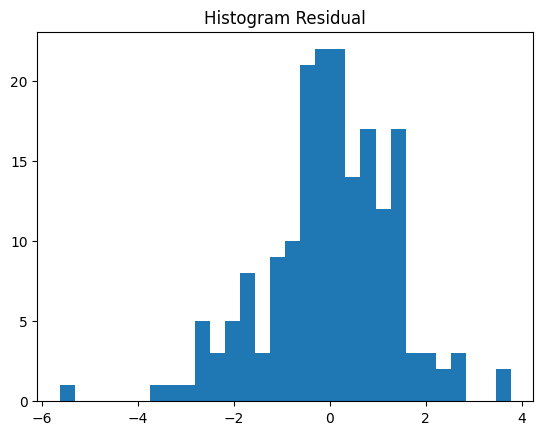

In [19]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

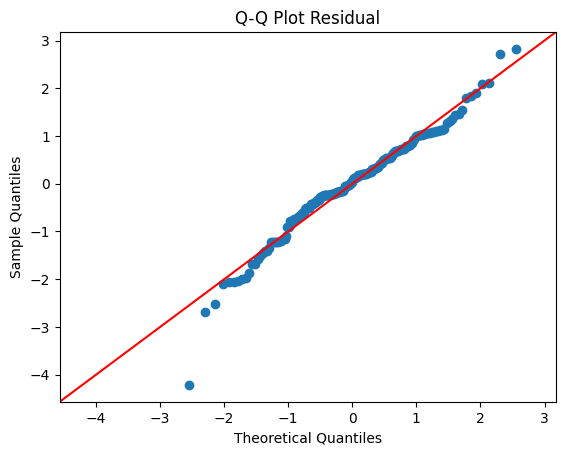

In [20]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [21]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.0022052074866929956
residual tidak berdistribusi normal


### Multikolinearitas

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                 Feature          VIF
0                  const  4174.396743
1           % BB Recycle    22.766451
2  Mean_Load KWH Refiner     8.003967
3           Mean_Creping    24.565958
4    Mean_Jet Wire Ratio     1.393476
5  coating_release_ratio     6.417221
